<a href="https://colab.research.google.com/github/reblekah/UASLidarWorkshop_SKC_2026/blob/main/UAS_Lidar_Workshop_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Headwaters Tech Hub Lidar Workshop
##September 25th, 2026
Welcome to the UAS Symposium and the lidar data use and management session!
All the code, data, and information shown in this workshop are open access and clearly documented for you to use.
This workshop is being taught in R (https://www.r-project.org/) which is a free an open source programming language built for statistics but with evolving uses and applications. Before we get started, go to the Runtime option on the ribbon above, and click "Change Runtime Type" followed by changing the runtime to "R" and the version to "2026.07"

Today's workshop is going to focus on the basics of lidar data management. Completing this workshop within Google Colab might be a little different than if you were going to run it on a


If you have any questions, feel free to contact me and see the sources below for more information.

Rebekah Fields: rebekah_fields@skc.edu

Sources:

USGS Lidar Data: https://apps.nationalmap.gov/lidar-explorer/#/

lidR package and documentation: https://r-lidar.github.io/lidRbook/

To quickly set up our working environment with access to data and packages (listed above), we need to start by making sure we have access to google drive.
This is a shortcut for today's workshop, there are other ways of accessing google drive for storage or file access that you can find here:

#Package Access and Download

In [ ]:
#This script was developed using R Version 4.6.0 - any later versions should update packages for full compatibility
#R.version.string

[1] "R version 4.6.0 (2026-04-24)"

This is some backend setup for functionality. It is required to run this code and make sure the packages we use are compatible. This whole section should take less than 2 minutes.

In [1]:
system("apt-get update -qq")
system2(
  "dpkg",
  c("--configure", "-a"),
  stdout = TRUE,
  stderr = TRUE
) |> cat(sep = "\n")
system2(
  "apt-get",
  c("-f", "install", "-y"),
  stdout = TRUE,
  stderr = TRUE
) |> cat(sep = "\n")


Reading package lists...
Building dependency tree...
Reading state information...
0 upgraded, 0 newly installed, 0 to remove and 188 not upgraded.


In [2]:
system2(
  "apt-get",
  c("install", "-y", "r-cran-raster","r-cran-terra", "r-cran-sf", "r-cran-sp","r-cran-lidr"),
  stdout = TRUE,
  stderr = TRUE
) |> cat(sep = "\n")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libcharls2 libgdal30 libglu1-mesa libproj22 libspatialite7 proj-bin
  r-cran-abind r-cran-bh r-cran-classint r-cran-e1071 r-cran-lazyeval
  r-cran-parallelly r-cran-proxy r-cran-rcpparmadillo r-cran-rgl r-cran-rlas
  r-cran-s2 r-cran-stars r-cran-units r-cran-wk
Suggested packages:
  r-cran-spdata r-cran-tinytest r-cran-mlbench r-cran-randomforest
  r-cran-sparsem r-cran-slam r-cran-covr r-bioc-ebimage r-cran-future
  r-cran-geometry r-cran-gstat r-cran-rcsf r-cran-rmcc r-cran-rjson
  r-cran-mapview r-cran-mapedit r-cran-cba r-cran-ncdf4 r-cran-igraph
  r-cran-rastervis r-cran-fields r-cran-exactextractr r-cran-pkgkitten
  r-cran-reticulate r-cran-deldir r-cran-orientlib r-cran-misc3d r-cran-magick
  r-cran-plotrix r-cran-interp r-cran-alphashape3d r-cran-js r-cran-webshot2
  r-cran-extrafont r-cran-manipulatewidget r-cran-crosstalk r-cran-v8
  r-cran

In [3]:
library(sf)
library(raster)
library(ggplot2)
library(dplyr)
library(sp)
library(lidR)

Warning message:
“package ‘sf’ was built under R version 4.6.1”
Linking to GEOS 3.12.1, GDAL 3.4.3, PROJ 8.2.1; sf_use_s2() is TRUE


Linked against: 3.12.1-CAPI-1.18.1 compiled against: 3.10.2-CAPI-1.16.0

It is probably a good idea to reinstall sf (and maybe lwgeom too)

Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.6.1”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:raster’:

    intersect, select, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘lidR’ was built under R version 4.6.1”

Attaching package: ‘lidR’


The following objects are masked from ‘package:raster’:

    projection, projection<-, wkt


The following object is masked from ‘package:sp’:

    wkt


The following object is masked from ‘package:sf’:

    st_concave_hull




#Lidar Data Access
Now we're going to access our lidar data. I already downloaded the compressed point cloud file, known as an .LAZ file. The link above is from the USGS Lidar Explorer, but any LAZ file will work here!

In [4]:
install.packages("googledrive")
library(googledrive)
drive_deauth()
file_id <- "1YoFI_9ExBibASqgiZyxRDnVh7VVwGr_g" #Actual link to shared file: https://drive.google.com/file/d/1YoFI_9ExBibASqgiZyxRDnVh7VVwGr_g/view?usp=drive_link
public_file <- drive_get(as_id(file_id))
drive_download(public_file, path = "lidar_site1.laz", overwrite = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

File downloaded:

• USGS_LPC_MT_Statewide_Phase2_2020_B20_297504.laz
  <id: 1YoFI_9ExBibASqgiZyxRDnVh7VVwGr_g>

Saved locally as:

• lidar_site1.laz



Start by accessing the LAZ file through the lidR package
The filter argument allows us to reduce initial computation by only targetting specific location or technical components of lidar data like the scan angle. See below for some general filtering categories. You can learn about other filtering methods by running the function readLAS(filter="-help").

We can also use the select function which works similarly to the filter option, but in this way we can select for the data we want to use. In our case, the x, y, z, and i values. This selects only the coordinates and intensity from those returns.

 Some general filtering categories:
* Filter points based on their coordinates.
* Filter points based on their return numbering.
* Filter points based on the scanline flags.
* Filter points based on their intensity.
* Filter points based on classifications or flags.
* Filter points based on their user data.
* Filter points based on their point source ID.
* Filter points based on their scan angle.
* Filter points based on their gps time.
* Filter points based on their RGB/CIR/NIR channels.
* Filter points based on their wavepacket.
* Filter points based on extra attributes.
* Filter points with simple thinning.
* Boolean combination of filters.


In [15]:
las1<-readLAS("lidar_site1.laz", select="xyzi")

Warning message:
“There are 2977 points flagged 'withheld'.”


We've imported the LAZ file, but "print(las1)" will show us what's inside.
First, the dataset is 1.6GB, which is only because we selected only the coordinates and intensity. If we would have imported all the data, we would be left with over 4GB of data. This can be processed with a fairly normal pc, but within Google's Colab environment, we are stuck with their maximum processing abilities.
It looks like we have about 58 million points, but there may be some repeats.

In [ ]:
print(las1)

class        : LAS (v1.4 format 6)
memory       : 1.6 Gb 
extent       : 297000, 298000, 504000, 505000 (xmin, xmax, ymin, ymax)
coord. ref.  : NAD83(2011) / Montana + NAVD88 height - Geoid18 (m) 
area         : 1 km²
points       : 59.98 million points
type         : airborne
density      : 59.98 points/m²


Let's filter see how complete the data is by examining the data itself for many common issues in lidar data.

In [16]:
las_check(las1)


 Checking the data
  - Checking coordinates... ✓
  - Checking coordinates type... ✓
  - Checking coordinates range... ✓
  - Checking coordinates quantization... ✓
  - Checking attributes type... ✓
  - Checking ReturnNumber validity... ✓
  - Checking NumberOfReturns validity... ✓
  - Checking ReturnNumber vs. NumberOfReturns... ✓
  - Checking RGB validity... ✓
  - Checking absence of NAs... ✓
  - Checking duplicated points...
    ⚠ 34934 points are duplicated and share XYZ coordinates with other points
  - Checking degenerated ground points... skipped
  - Checking attribute population... ✓
  - Checking gpstime incoherances skipped
  - Checking flag attributes... ✓
  - Checking user data attribute... skipped
 Checking the header
  - Checking header completeness... ✓
  - Checking scale factor validity... ✓
  - Checking point data format ID validity... ✓
  - Checking extra bytes attributes validity... ✓
  - Checking the bounding box validity... ✓
  - Checking coordinate reference system..

If you'll notice "Checking duplicate points" has found that 34k of those points have matching coordinates with other points. This isn't uncommon in lidar data, so let's drop those for simplicity.

In [17]:
las_clean<-filter_duplicates(las1)

And again, because this is a large dataset, let's remove our original data. We can always access again if we need to.
Remember, this code is just a sample and there are ways to manage large datasets. I would be happy to help make recommendations or provide support if you need.

In [20]:
rm(las1) #remove the original lidar file - we can always get it back!
gc() #clear out some of Colab's unused memory

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5097813,272.3,9128771,487.6,7918911,423.0
Vcells,217342151,1658.2,615491577,4695.9,757166814,5776.8


We've filtered our point data to prevent duplicates, but what does the data even look like?

There are many ways to customize lidar plots but for now let's just make sure our data make sense.

In [ ]:
plot(las_clean)

Warning message in rgl.init(initValue, onlyNULL):
“RGL: unable to open X11 display”
Warning message:
“'rgl.init' failed, will use the null device.
See '?rgl.useNULL' for ways to avoid this warning.”


In [21]:
#select 200m extent to plot side profile
p1<-c(297100,504400)
p2<-c(297270,504500)
las_clipped<-clip_transect(las_clean, p1, p2, width = 2, xz=TRUE)

What the graph below shows us is a side profile of any points that fall within the p1,p2 x and y min/max. This type of view is useful for seeing vegetation on the surface. Let's look at that.

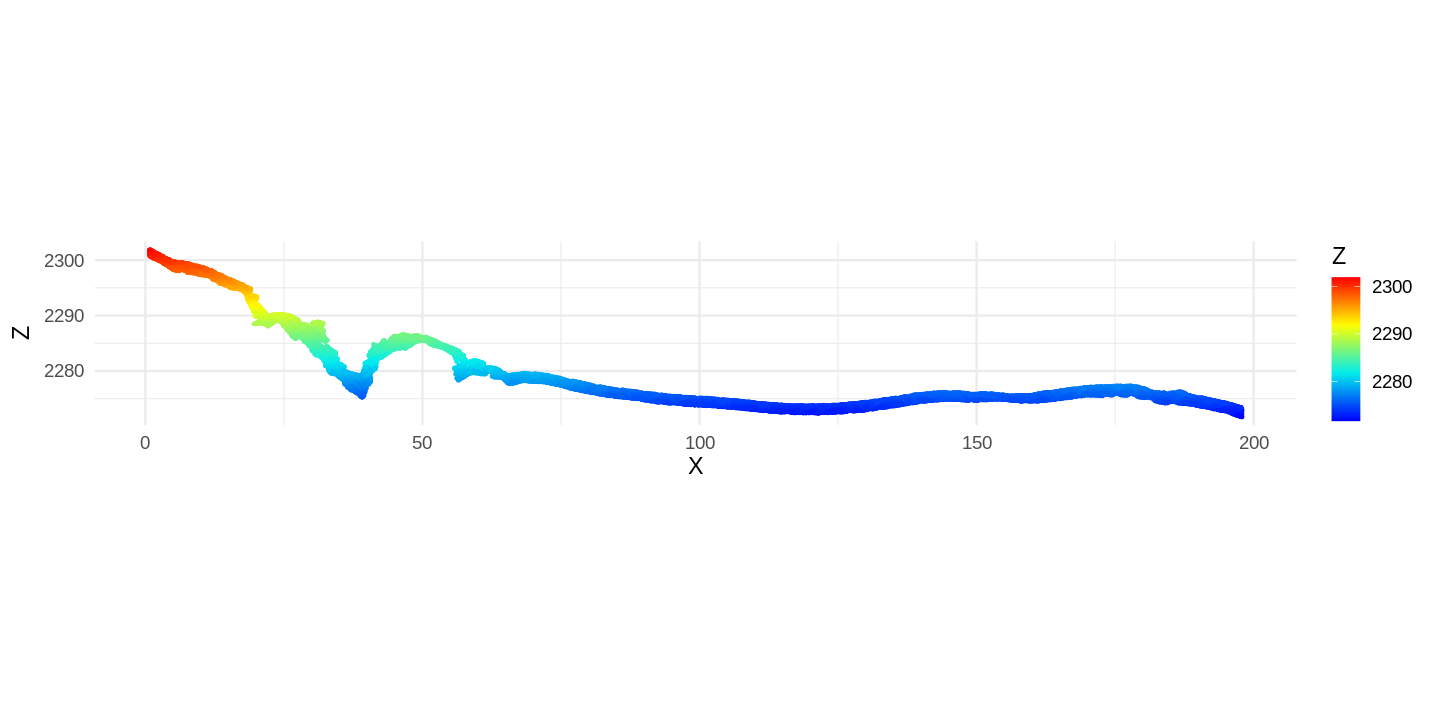

In [33]:
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(payload(las_clipped),aes(X,Z,color = Z)) +
  geom_point(size = 0.5)+
  coord_equal()+
  theme_minimal(base_size=14)+
  scale_color_gradientn(colours=height.colors(50))

A